# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('cleaned_airbnb_data_6.csv')
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_missing_flag,host_response_time_missing_flag
0,155305,https://www.airbnb.com/rooms/155305,20250922033920,2025-09-22,city scrape,Cottage! BonPaul + Sharky's Hostel,West Asheville Cottage within walking distance...,"We are within easy walk of pubs, breweries, mu...",https://a0.muscache.com/pictures/hosting/Hosti...,746673,...,4.92,4.58,t,8,2,3,3,2.69,False,False
1,197263,https://www.airbnb.com/rooms/197263,20250922033920,2025-09-22,city scrape,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,961396,...,4.86,4.97,f,2,1,1,0,0.56,False,False
2,209068,https://www.airbnb.com/rooms/209068,20250922033920,2025-09-22,city scrape,Terrace Cottage,Located in one of Asheville's oldest historic ...,Our beautiful Grove Park Historic District clo...,https://a0.muscache.com/pictures/1829924/9f3bf...,1029919,...,4.94,4.80,f,1,1,0,0,0.39,False,True
3,246315,https://www.airbnb.com/rooms/246315,20250922033920,2025-09-22,city scrape,Asheville Dreamer's Cabin,"Hi there,<br />I am usually here half of each ...",NaN,https://a0.muscache.com/pictures/5908617/cfe79...,1292070,...,4.67,4.59,f,3,2,1,0,0.31,False,False
4,314540,https://www.airbnb.com/rooms/314540,20250922033920,2025-09-22,city scrape,Asheville Urban Farmhouse Entire Home 4.6 mi t...,Farmhouse in the city is OPEN! This charming 1...,City vibes with country appeal. Peaceful neigh...,https://a0.muscache.com/pictures/hosting/Hosti...,381660,...,4.91,4.91,t,1,1,0,0,0.22,False,False


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



In [22]:
df.describe()


,id,scrape_id,host_id,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.852000e+03,2.852000e+03,2.852000e+03,2487.000000,2602.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,...,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2852.000000,2852.000000,2852.000000,2852.000000,2609.000000
mean,4.968465e+17,2.025092e+13,1.715546e+08,0.981709,0.927248,43.521388,80.851332,28791.994741,35.574867,-82.557548,...,4.905592,4.944028,4.939931,4.882672,4.831617,9.646564,9.229313,0.362202,0.016480,2.177972
std,5.463762e+17,0.000000e+00,1.775532e+08,0.110429,0.184376,190.236504,423.573884,31.000780,0.049634,0.048434,...,0.165997,0.131946,0.147253,0.167017,0.195331,23.300514,23.346535,1.401363,0.215357,1.991614
min,1.553050e+05,2.025092e+13,4.134000e+03,0.000000,0.000000,0.000000,0.000000,28704.000000,35.427050,-82.669890,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.020000
25%,3.352236e+07,2.025092e+13,2.923683e+07,1.000000,0.960000,1.000000,1.000000,28801.000000,35.554760,-82.591813,...,4.880000,4.940000,4.930000,4.850000,4.780000,1.000000,1.000000,0.000000,0.000000,0.690000
50%,5.356557e+07,2.025092e+13,1.122954e+08,1.000000,0.990000,2.000000,3.000000,28803.000000,35.586754,-82.555860,...,4.960000,4.980000,4.980000,4.920000,4.880000,2.000000,1.000000,0.000000,0.000000,1.640000
75%,1.000807e+18,2.025092e+13,2.472814e+08,1.000000,1.000000,8.000000,10.250000,28806.000000,35.605795,-82.518954,...,5.000000,5.000000,5.000000,4.970000,4.940000,4.000000,4.000000,0.000000,0.000000,3.090000
max,1.513870e+18,2.025092e+13,7.125037e+08,1.000000,1.000000,1649.000000,3502.000000,28806.000000,35.658070,-82.460210,...,5.000000,5.000000,5.000000,5.000000,5.000000,113.000000,113.000000,14.000000,3.000000,20.290000


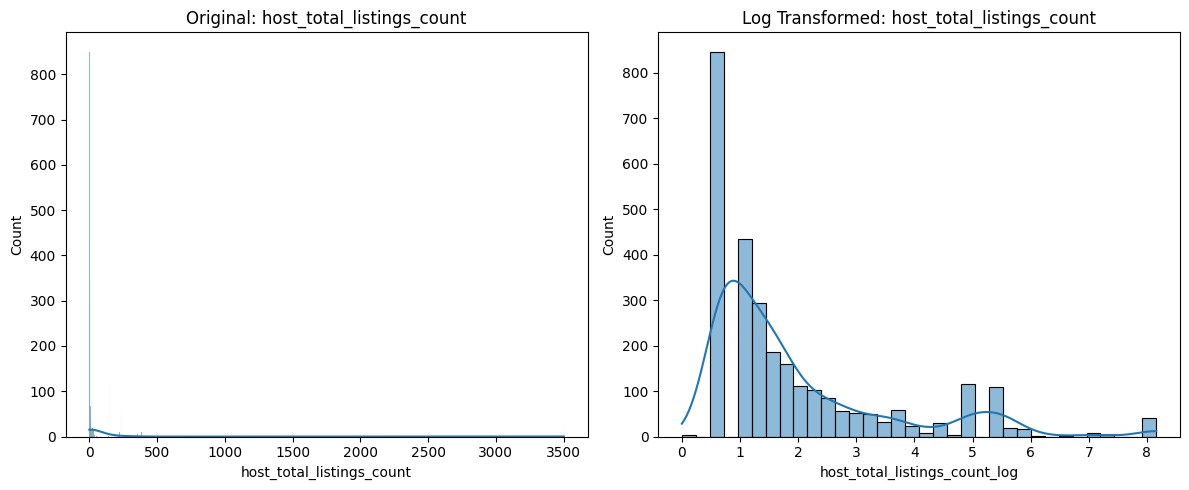

In [23]:
# Original histogram
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['host_total_listings_count'], kde=True)
plt.title('Original: host_total_listings_count')


# Apply log transformation (using log1p to handle 0 values)
df['host_total_listings_count_log'] = np.log1p(df['host_total_listings_count'])


# Transformed histogram
plt.subplot(1, 2, 2)
sns.histplot(df['host_total_listings_count_log'], kde=True)
plt.title('Log Transformed: host_total_listings_count')


plt.tight_layout()
plt.show()


### ✍️ Your Response: 🔧
1. I examined the host total listings count column since it was extremely right skewed.

2. I tried using the log transformation to reduce the impact of the heavy values. This column included zeros and had a heavy right skew so a log transformation made sense.

3. Although the transformed version of the column was still skewed it was now easier to use for modeling, analysis and visualization

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# Min-Max scale 'availability_365'
min_max_scaler = MinMaxScaler()
df['availability_365_scaled'] = min_max_scaler.fit_transform(df[['availability_365']])


# Z-score scale 'review_scores_cleanliness'
# Handle potential NaN values by dropping them for scaling, or imputing if preferred.
# For demonstration, we'll fill with median before scaling to keep all rows.
df['review_scores_cleanliness_filled'] = df['review_scores_cleanliness'].fillna(df['review_scores_cleanliness'].median())
standard_scaler = StandardScaler()
df['review_scores_cleanliness_scaled'] = standard_scaler.fit_transform(df[['review_scores_cleanliness_filled']])


# Display descriptive statistics for comparison
print("\nDescriptive statistics for original and scaled 'availability_365':")
print(df[['availability_365', 'availability_365_scaled']].describe())


print("\nDescriptive statistics for original and scaled 'review_scores_cleanliness':")
print(df[['review_scores_cleanliness', 'review_scores_cleanliness_scaled']].describe())




Descriptive statistics for original and scaled 'availability_365':
       availability_365  availability_365_scaled
count       2852.000000              2852.000000
mean         223.555049                 0.612480
std          122.247121                 0.334924
min            0.000000                 0.000000
25%          116.000000                 0.317808
50%          263.000000                 0.720548
75%          332.000000                 0.909589
max          365.000000                 1.000000

Descriptive statistics for original and scaled 'review_scores_cleanliness':
       review_scores_cleanliness  review_scores_cleanliness_scaled
count                2609.000000                      2.852000e+03
mean                    4.905592                      4.214176e-15
std                     0.165997                      1.000175e+00
min                     1.000000                     -2.452132e+01
25%                     4.880000                     -1.268507e-01
50%         

### ✍️ Your Response: 🔧
1. The 2 columns i scaled were the availability 365 using the min max scaler and review_scores_cleanliness using the standard scaler.

2. scaled values are more useful when trying to compare 2 varaibles with different ranges. These variables could have a strong relationship but it is difficult to interpret when their ranges are different

3. The marketing team can benefit from the availability scaled and review scores cleanliness scaled as they can use this to determine which listings they want to push to promote more as it will be good promotion for airbnb themselves. The analytics team and listing managers can also use both simultaneously to see the relationship between availability and cleanliness of an airbnb which could be good insight to determine how to improve.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [25]:
# Fill NaN values in 'reviews_per_month' with 0, assuming no reviews means 0 reviews.
df['reviews_per_month_filled'] = df['reviews_per_month'].fillna(0)


# Define the bins and labels for 'reviews_per_month'
# Based on df.describe() output, typical ranges for reviews_per_month
# min: 0.01, 25%: 0.40, 50%: 1.05, 75%: 2.21, max: 13.88
bins = [df['reviews_per_month_filled'].min() - 0.1, 0.5, 2.5, df['reviews_per_month_filled'].max() + 0.1]
labels = ["Low Activity", "Medium Activity", "High Activity"]


# Group the values into bins
df['review_activity_category'] = pd.cut(
    df['reviews_per_month_filled'],
    bins=bins,
    labels=labels,
    right=True, # Bins are right-inclusive by default
    include_lowest=True # Include the lowest value
)


# Print .value_counts() on the new column to see the distribution
print("Distribution of 'review_activity_category':\n")
display(df['review_activity_category'].value_counts())


# Display the head of the DataFrame with the new column for a quick check
display(df[['reviews_per_month', 'reviews_per_month_filled', 'review_activity_category']].head())


Distribution of 'review_activity_category':



,count
review_activity_category,
Medium Activity,1213
High Activity,877
Low Activity,762


,reviews_per_month,reviews_per_month_filled,review_activity_category
0,2.69,2.69,High Activity
1,0.56,0.56,Medium Activity
2,0.39,0.39,Low Activity
3,0.31,0.31,Low Activity
4,0.22,0.22,Low Activity


### ✍️ Your Response: 🔧
1. The column i grouped was the reviews per month column. i used 3 categories High activity, medium activity and low activity.

2. Somone may prefer the grouped view when looking at the data at a glance as it is much easier to interpret as clear groupings.

3. This may help the marketing team at airbnb to see the performance of certain listings/bookings through the review activity. They could use this information to make decisions on promotions.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [26]:
 #1. Create a ratio: reviews per month / calculated host listings count
# Handle potential division by zero in 'calculated_host_listings_count'
df['reviews_per_month_per_listing'] = df.apply(
    lambda row: row['reviews_per_month_filled'] / row['calculated_host_listings_count']
    if row['calculated_host_listings_count'] > 0 else 0,
    axis=1
)


# 2. Create a flag for high review scores
# Fill NaN values in review_scores_value with a neutral value (e.g., 0 or median) before comparison if needed
# For simplicity, we'll assume NaN means not greater than 4.5 or handle with .fillna(0) for numerical comparison
df['high_review_score_flag'] = (df['review_scores_value'] > 4.5).astype(int)


print("New column 'reviews_per_month_per_listing' created:")
display(df[['reviews_per_month_filled', 'calculated_host_listings_count', 'reviews_per_month_per_listing']].head())


print("\nNew column 'high_review_score_flag' created:")
display(df[['review_scores_value', 'high_review_score_flag']].head())


New column 'reviews_per_month_per_listing' created:


,reviews_per_month_filled,calculated_host_listings_count,reviews_per_month_per_listing
0,2.69,8,0.336250
1,0.56,2,0.280000
2,0.39,1,0.390000
3,0.31,3,0.103333
4,0.22,1,0.220000



New column 'high_review_score_flag' created:


,review_scores_value,high_review_score_flag
0,4.58,1
1,4.97,1
2,4.80,1
3,4.59,1
4,4.91,1


### ✍️ Your Response: 🔧 🔧
1. the 2 new columns i created were reviews per month per listing and high review score flag
2. the marketing team at airbnb could use the new flag column and listing managers could use the per month per listing column

3. the marketing team at airbnb could use the high review score flag to determine which listings they want to promote more since these would give them a better reputation. The reviews per month per lisitng could be the lisitng managers to see whether they are reaching the activity they want in comparison to the listings they have.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [27]:
# One-hot encode 'room_type'
df = pd.get_dummies(df, columns=['property_type'], prefix='property')


print("DataFrame head with one-hot encoded 'property_type' columns:")
display(df.filter(like='property_').head())


DataFrame head with one-hot encoded 'property_type' columns:


,property_Barn,property_Camper/RV,property_Campsite,property_Cave,property_Earthen home,property_Entire bungalow,property_Entire cabin,property_Entire chalet,property_Entire condo,property_Entire cottage,...,property_Private room in treehouse,property_Room in boutique hotel,property_Room in hotel,property_Shared room,property_Shared room in hostel,property_Shipping container,property_Tent,property_Tiny home,property_Treehouse,property_Yurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


### ✍️ Your Response: 🔧
1. The column i chose to encode was property type
2. I chose to use one hot encoding as the categories were nominal
3. we can use this transformation in predictive pricing models as the dummy variables can be used in statistical analytics. It will be easier to compare performance based on property type on a dashboard or business report.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [29]:
df.to_csv("cleaned_airbnb_data_7.csv", index=False)

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The transformation I felt was the most interesting was the scaling. Its easy to say 2 variables are correlated but I hadnt really considered the difficulty in interpreting them when the ranges between the 2 are different. After completing the transformation I understand the importance and how beneficial it can be.

2. the high review score flag may be most useful to a planner as options are necessary but quality is as well. Having a high review score flag makes those decisions much easier.

3. make sure that all the data is standardized so that one can easily filter from property type, rating, cleanliness, etc.

4. My customized learning outcome including being able to clean, organize and prepare data for analysis while also being able to interpret / communicate finidngs across professional settings outside of accounting. I think learning how to transform data in ways that may be easier to digest to marketing teams or management teams falls under my learning outcomes as I am doing just as I said, organizing and preparing data to be interpretable to others.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [30]:
!jupyter nbconvert --to html "assignment_07_VegaSamantha.ipynb"

[NbConvertApp] Converting notebook assignment_07_VegaSamantha.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 408745 bytes to assignment_07_VegaSamantha.html
